# Clase 16: Clustering K-means y Jerárquico

En esta notebook vamos a explorar dos métodos de clusterización vistos en la clase teórica. Los métodos de clusterización que veremos corresponden a la rama de ML de aprendizaje no supervisado donde la idea principal es encontrar grupos en los datos que sean similares a otros datos del mismo grupo y lo menos similar posible a datos en otros grupos.

El primer método es el algoritmo de partición **K-Means**, que aplicaremos al dataset de Urban Areas (áreas urbanas), para tratar de agrupar ciudades según sus características de calidad de vida, economía, y otros indicadores.

El dataset contiene 267 ciudades de todo el mundo con 17 métricas diferentes que evalúan aspectos como vivienda, costo de vida, startups, conectividad, seguridad, salud, educación, calidad ambiental, economía, impuestos, acceso a internet, cultura, tolerancia y espacios al aire libre.

El segundo método es el **Hierarchical Clustering** (clustering jerárquico), que también aplicaremos al dataset de áreas urbanas para comparar los resultados con K-Means y entender mejor cómo se agrupan las ciudades según sus similitudes.

In [1]:
# importamos las librerías usuales de python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importamos los algoritmos de clusterizacion a utilizar en esta notebook
from sklearn.cluster import KMeans                    # K-means
from sklearn.cluster import AgglomerativeClustering   # Clustering jerárquico

Para agilizar el proceso de clusterización vamos a identificar las componentes principales mediante PCA. Dado que las variables tienen diferentes escalas, primero estandarizaremos los datos antes de aplicar PCA.

In [2]:
# Clase para realizar componentes principales
from sklearn.decomposition import PCA

# Estandarizador (transforma las variables en z-scores)
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler() # Creamos el estandarizador

## [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans)

El método de clusterización "K-Means" busca encontrar *k* clusters de modo tal que se minimice la varianza intra-cluster medida, usualmente, como el cuadrado de la distancia euclídea. Para ello el algoritmo empieza encontrando *k centroids* y le asigna a cada sample la etiqueta correspondiente a la del centroid más cercano. Una vez actualizadas las etiquetas de todas las samples, calcula la posición de los k centroids (como el promedio de las features de las samples de cada cluster) y vuelve a asignar etiquetas a cada sample de acuerdo a la distancia al centroid más cercano. Hace estos dos pasos hasta que no haya más cambios de etiqueta.

Debido a esta inicialización aleatoria de los k centroids el output del modelo puede variar al aplicarlo otra vez a la misma data. Por ello se repite este procedimiento n_init=10 veces y el output final es el que mejor resultado tuvo al minimizar la función objetivo (varianza intra-cluster).

### Clustering en el dataset de Urban Areas

Importamos el dataset de áreas urbanas desde el archivo CSV.

El dataset contiene información de 267 ciudades del mundo con las siguientes características:
- **UA_Name**: Nombre de la ciudad
- **UA_Country**: País
- **UA_Continent**: Continente
- **17 métricas numéricas**: Housing, Cost of Living, Startups, Venture Capital, Travel Connectivity, Commute, Business Freedom, Safety, Healthcare, Education, Environmental Quality, Economy, Taxation, Internet Access, Leisure & Culture, Tolerance, Outdoors

Cada métrica está en una escala (generalmente de 0 a 10) donde valores más altos indican mejor rendimiento en esa categoría.

In [3]:
# Cargamos el dataset de áreas urbanas
df = pd.read_csv('data/uaScoresDataFrame-csv-2.csv')

# Guardamos los nombres de las ciudades y metadata
city_names = df['UA_Name'].values
city_countries = df['UA_Country'].values
city_continents = df['UA_Continent'].values

# Extraemos solo las columnas numéricas (features) - columnas desde la 4ta en adelante
data = df.iloc[:, 3:].values

print('Dimensión de los datos: {}'.format(data.shape))
print('Número de ciudades: {}'.format(len(city_names)))
print('Número de características: {}'.format(data.shape[1]))
print('\nPrimeras 5 ciudades:', city_names[:5])
print('\nNombres de las características:')
print(df.columns[3:].tolist())

Dimensión de los datos: (266, 17)
Número de ciudades: 266
Número de características: 17

Primeras 5 ciudades: <StringArray>
['Aarhus', 'Adelaide', 'Albuquerque', 'Almaty', 'Amsterdam']
Length: 5, dtype: str

Nombres de las características:
['Housing', 'Cost of Living', 'Startups', 'Venture Capital', 'Travel Connectivity', 'Commute', 'Business Freedom', 'Safety', 'Healthcare', 'Education', 'Environmental Quality', 'Economy', 'Taxation', 'Internet Access', 'Leisure & Culture', 'Tolerance', 'Outdoors']


Primero estandarizamos los datos ya que las diferentes métricas pueden tener escalas distintas. La estandarización convierte cada variable a z-scores (media=0, desviación estándar=1), lo cual es crucial antes de aplicar PCA.

In [4]:
# Estandarizamos los datos
data_scaled = std_scale.fit_transform(data)

# Creación del modelo de PCA con 10 componentes
pca = PCA(n_components = 10)

# Ajuste y transformación de los datos estandarizados
pca.fit(data_scaled)
X_pca = pca.transform(data_scaled)

# Mostramos la varianza explicada por cada componente
print('Varianza explicada por cada componente:')
print(pca.explained_variance_ratio_)
print('\nVarianza total explicada por las {} componentes: {:.2f}%'.format(
    pca.n_components, 
    pca.explained_variance_ratio_.sum() * 100
))

Varianza explicada por cada componente:
[0.29798484 0.15161472 0.1224869  0.07647805 0.07046698 0.05649736
 0.04063737 0.03903726 0.03432299 0.02496577]

Varianza total explicada por las 10 componentes: 91.45%


Chequeamos que la matriz X_pca tiene las dimensiones correctas (267 ciudades, 10 componentes principales)

In [5]:
X_pca.shape

(266, 10)

Ploteamos el dataset en el espacio de las primeras dos componentes principales. Cada punto representa una ciudad.

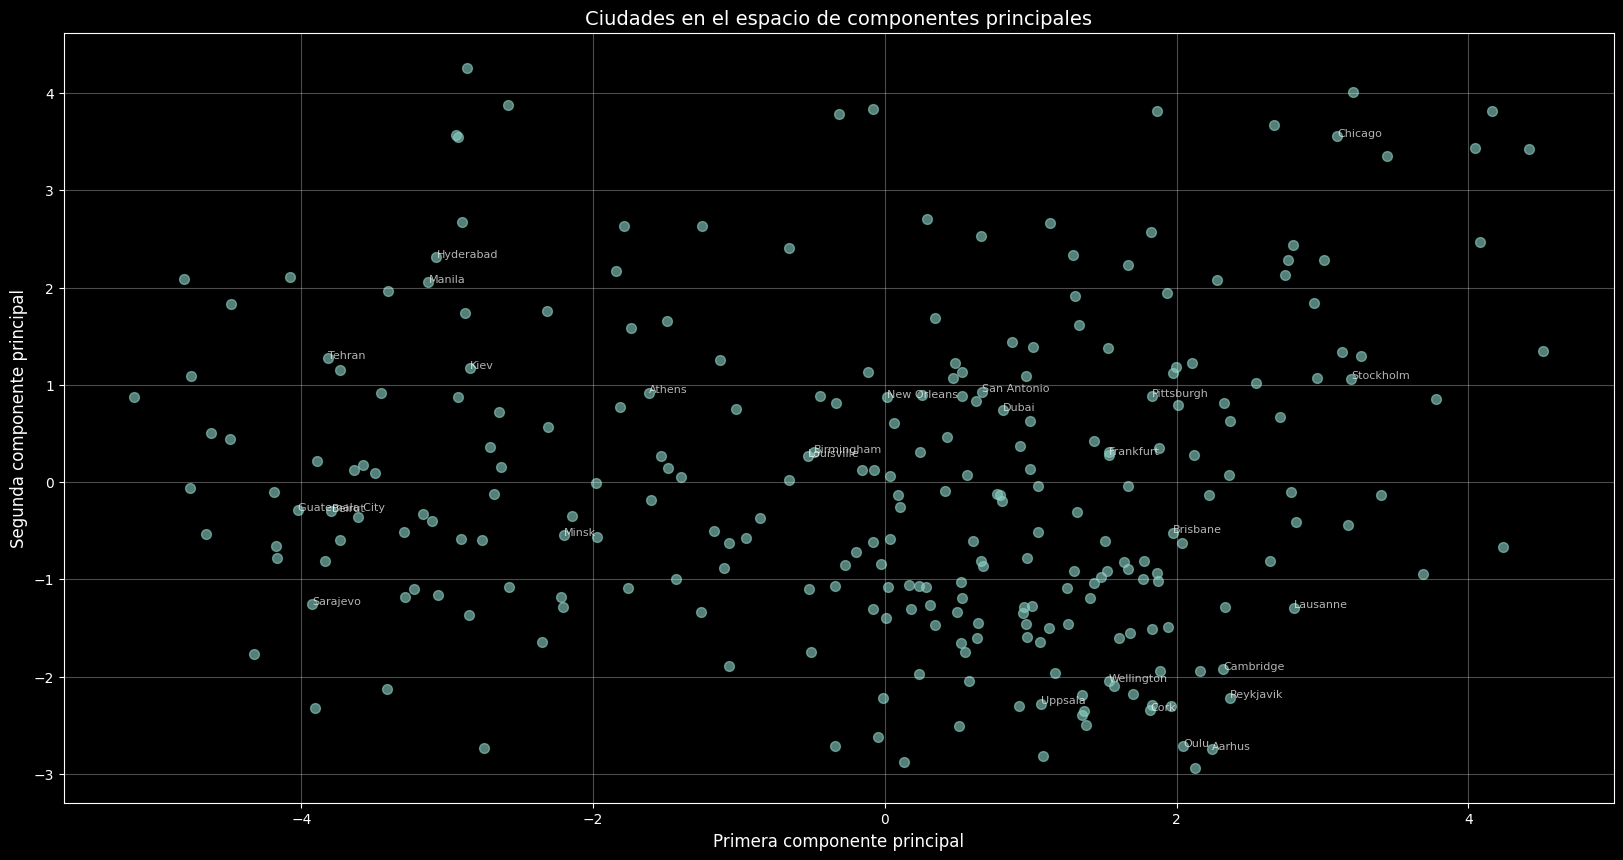

In [6]:
fig, ax = plt.subplots(figsize = (20, 10))

# Hacemos un scatter plot de cada ciudad
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50)

# Mostramos el nombre de algunas ciudades importantes (para no saturar el gráfico)
# Seleccionamos cada 10 ciudades para etiquetar
for i in range(0, len(city_names), 10):
    ax.text(X_pca[i, 0], X_pca[i, 1], s=city_names[i], fontsize=8, alpha=0.7)

ax.set_xlabel('Primera componente principal', fontsize=12)
ax.set_ylabel('Segunda componente principal', fontsize=12)
ax.set_title('Ciudades en el espacio de componentes principales', fontsize=14)
ax.grid(True, alpha=0.3)

Ahora aplicamos el método de clusterización K-Means para agrupar las ciudades en base a sus componentes principales. Empezaremos con k=6 clusters para identificar diferentes tipos de ciudades según sus características.

In [7]:
# Creación del modelo KMeans con k = 6
kmeans = KMeans(n_clusters=6, random_state=42)

# Ajuste del modelo a los datos reducidos en componentes principales
kmeans.fit(X_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Para acceder a las etiquetas que le asignó el modelo a cada ciudad usamos 'kmeans.labels_'

In [8]:
# Veamos cuántas ciudades hay en cada cluster
unique_labels, counts = np.unique(kmeans.labels_, return_counts=True)
print('Número de ciudades por cluster:')
for label, count in zip(unique_labels, counts):
    print(f'  Cluster {label}: {count} ciudades')

Número de ciudades por cluster:
  Cluster 0: 51 ciudades
  Cluster 1: 12 ciudades
  Cluster 2: 83 ciudades
  Cluster 3: 35 ciudades
  Cluster 4: 43 ciudades
  Cluster 5: 42 ciudades


Visualizamos las ciudades en el espacio de las primeras dos componentes principales con colores según el cluster asignado. También graficamos con una "X" el centroid de cada cluster.

Para acceder a la posición de los centroids en el espacio de componentes principales usamos 'kmeans.cluster_centers_'

In [9]:
# Guardo las posiciones de los centroids
centroids = kmeans.cluster_centers_

# Printeo las dimensiones de las posiciones
print("Shape de los centroids:",centroids.shape)
# Printeo las posiciones de los primeros 3 centroids en sus primeras dos componentes principales
print('\nPrimeros 3 centroids (PC1, PC2):')
print(centroids[:3,[0,1]])

Shape de los centroids: (6, 10)

Primeros 3 centroids (PC1, PC2):
[[-3.43496379  0.54488894]
 [-2.09129779 -1.4842407 ]
 [ 1.4336287  -1.26869604]]


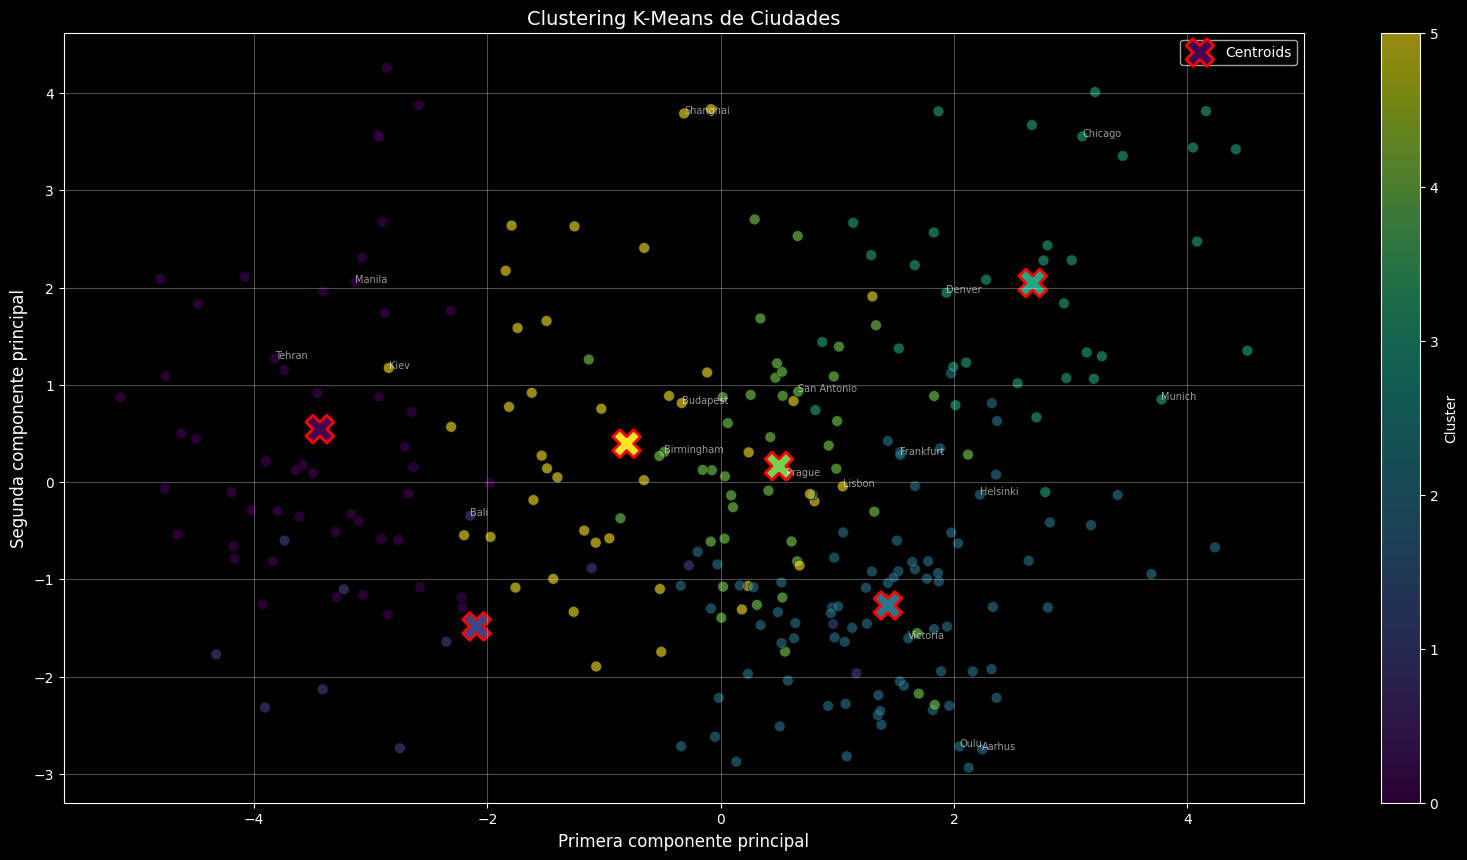

In [10]:
fig, ax = plt.subplots(figsize = (20, 10))

# Hacemos un scatter plot coloreado por cluster
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis', 
                     alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

# Graficamos los centroids
ax.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=400, linewidths=2,
            c=np.unique(kmeans.labels_), cmap='viridis', edgecolors='red', label='Centroids')

# Añadimos leyenda de colores
plt.colorbar(scatter, label='Cluster')

# Mostramos algunos nombres de ciudades (cada 15 para no saturar)
for i in range(0, len(city_names), 15):
    ax.text(X_pca[i, 0], X_pca[i, 1], s=city_names[i], fontsize=7, alpha=0.6)

ax.set_xlabel('Primera componente principal', fontsize=12)
ax.set_ylabel('Segunda componente principal', fontsize=12)
ax.set_title('Clustering K-Means de Ciudades', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

Analicemos qué ciudades están en cada cluster y cuáles son sus características promedio.

In [11]:
# Análisis de cada cluster
labels = kmeans.labels_
feature_names = df.columns[3:].tolist()

for cluster_id in range(6):
    print(f'\n{"="*80}')
    print(f'CLUSTER {cluster_id}')
    print(f'{"="*80}')
    
    # Ciudades en este cluster
    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_cities = city_names[cluster_indices]
    
    print(f'\nNúmero de ciudades: {len(cluster_cities)}')
    print(f'\nPrimeras 10 ciudades:')
    for i, city in enumerate(cluster_cities[:10]):
        print(f'  {i+1}. {city}')
    
    # Características promedio del cluster
    cluster_data = data[cluster_indices]
    cluster_means = cluster_data.mean(axis=0)
    
    print(f'\nCaracterísticas promedio del cluster (top 5):')
    # Ordenamos las características por valor promedio
    sorted_indices = np.argsort(cluster_means)[::-1]
    for i in range(5):
        idx = sorted_indices[i]
        print(f'  {feature_names[idx]}: {cluster_means[idx]:.2f}')
    
    print(f'\nCaracterísticas más bajas (bottom 5):')
    for i in range(5):
        idx = sorted_indices[-(i+1)]
        print(f'  {feature_names[idx]}: {cluster_means[idx]:.2f}')


CLUSTER 0

Número de ciudades: 51

Primeras 10 ciudades:
  1. Almaty
  2. Ankara
  3. Asuncion
  4. Baku
  5. Beirut
  6. Belgrade
  7. Bengaluru
  8. Cairo
  9. Cape Town
  10. Caracas

Características promedio del cluster (top 5):
  Housing: 8.89
  Cost of Living: 8.61
  Safety: 6.79
  Taxation: 5.61
  Tolerance: 5.49

Características más bajas (bottom 5):
  Education: 0.71
  Venture Capital: 1.60
  Travel Connectivity: 2.16
  Environmental Quality: 3.27
  Internet Access: 3.30

CLUSTER 1

Número de ciudades: 12

Primeras 10 ciudades:
  1. Andorra
  2. Bali
  3. Belize City
  4. Bozeman
  5. Gibraltar
  6. Havana
  7. La Paz
  8. Managua
  9. Panama
  10. Portland

Características promedio del cluster (top 5):
  Safety: 7.88
  Tolerance: 7.08
  Healthcare: 5.06
  Environmental Quality: 4.94
  Taxation: 4.65

Características más bajas (bottom 5):
  Venture Capital: 0.31
  Cost of Living: 0.63
  Commute: 0.92
  Education: 0.93
  Travel Connectivity: 1.40

CLUSTER 2

Número de ciudades

Los clusters agrupan ciudades con características similares. Por ejemplo, podríamos encontrar:
- Clusters de ciudades con alta calidad de vida (buena salud, educación, seguridad)
- Clusters de ciudades emergentes con alto emprendimiento pero menor infraestructura
- Clusters de ciudades económicamente desarrolladas pero con alto costo de vida
- Clusters de ciudades con buen balance entre costo y calidad de vida

### Elección del número de clusters *k*

No hay un consenso en cómo elegir el parámetro *k* para el método KMeans. En algunos casos tenemos una idea de en cuántos grupos deberían estar divididos nuestros datos y simplemente elegimos ese número. Pero en muchos otros casos esta información no la tenemos al momento de hacer el clustering.

En esta parte vamos a ver dos approachs para la elección de k:
1. Método del codo
2. Coeficiente de Silhouette

#### 1 [Método del codo](https://en.wikipedia.org/wiki/Elbow_method_(clustering)#:~:text=In%20cluster%20analysis%2C%20the%20elbow,number%20of%20clusters%20to%20use.)

Se hace un grafico de la función objetivo en función de la elección de k y se elige el k correspondiente al punto donde agregar un cluster más no baja significativamente el valor que queremos minimzar. Esto se puede detectar a ojo o utilizando algún paquete de python como ['kneed'](https://raghavan.usc.edu//papers/kneedle-simplex11.pdf)

In [12]:
from kneed import KneeLocator # importamos el paquete para detectar el codo

Vamos a aplicar el método KMeans al dataset de ciudades cambiando el número de clusters k y guardaremos el puntaje de la función objetivo, SSE (suma de los cuadrados de la distancia euclidea), en una lista.

In [13]:
sse = [] # acá vamos a guardar el puntaje de la función objetivo

for k in range(1, 20):
    print(k)
    kkmeans = KMeans(n_clusters=k, random_state=42)
    kkmeans.fit(X_pca)
    sse.append(kkmeans.inertia_)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


Vamos a graficar SEE en función del número de clusters k

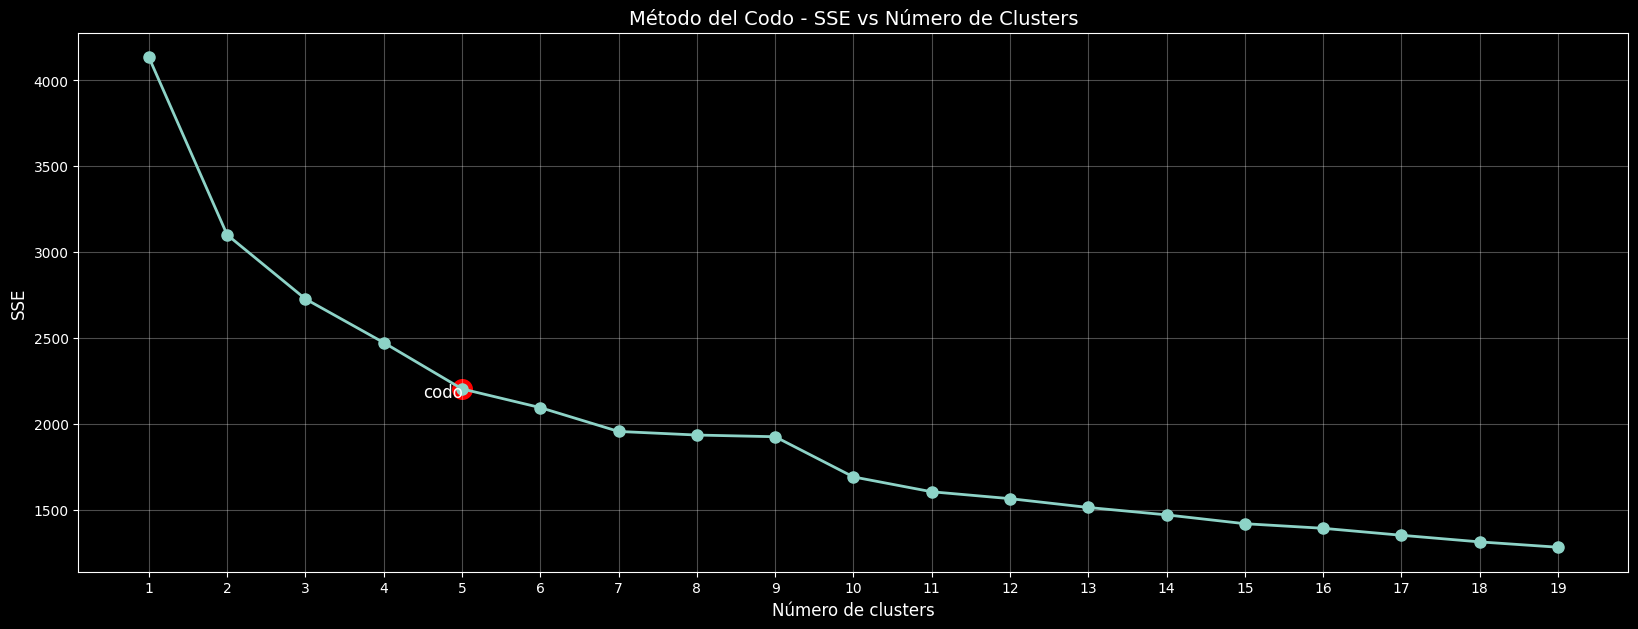

In [14]:
fig, ax = plt.subplots(figsize = (20, 7))

# esta dos lineas las agrego para que se vea la elección de KneeLocator para el codo en este gráfico
# Primero calculamos el codo
kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing")
if kl.elbow:
    ax.scatter(kl.elbow, sse[kl.elbow-1], color='red', s=200)
    ax.text(kl.elbow-0.5, sse[kl.elbow-1]-50, s="codo", fontsize=12)

# estas lineas son el grafico de SSE vs K
ax.plot(range(1, 20), sse, marker='o', linewidth=2, markersize=8)
ax.set_xticks(range(1, 20))
ax.set_xlabel("Número de clusters", fontsize=12)
ax.set_ylabel("SSE", fontsize=12)
ax.set_title("Método del Codo - SSE vs Número de Clusters", fontsize=14)
ax.grid(True, alpha=0.3)

En este plot podemos ver dos cosas:
1. SSE es monótonamente decreciente: al agregar un cluster la distancia entre todas las samples a los centroides siempre va a reducirse
2. A ojo distinguimos un codo entre k=5 y k=9 porque al agregar más clusters aumentamos la complejidad del modelo pero SEE disminuye en menor proporción

Usamos la función 'KneeLocator' para detectar el codo. Para ello le tenemos que pasar los valores de K, SEE, la forma de la fución (cóncava o convexa) y la dirección (creciente o decreciente)

In [15]:
kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing")

print("El codo está en k =", kl.elbow)

El codo está en k = 5


Veamos entonces cómo se ve el modelo con el k óptimo sugerido por el método del codo para el dataset de áreas urbanas.

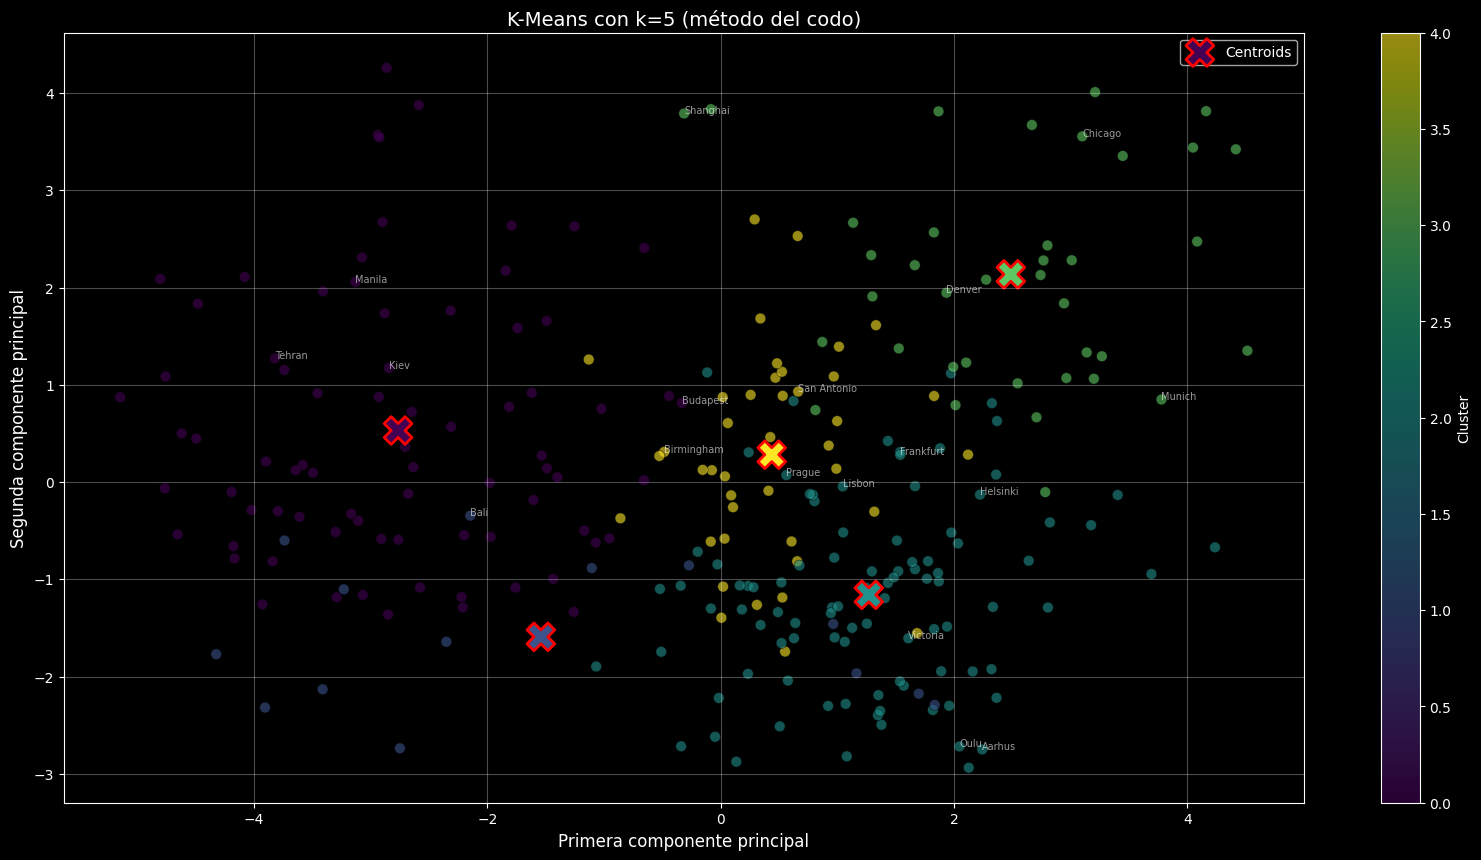

In [16]:
# Obtener k óptimo
k_optimal = kl.elbow if kl.elbow else 6

# Creación del modelo KMeans con k óptimo
kmeans_opt = KMeans(n_clusters=k_optimal, random_state=42)

# Ajuste del modelo a los datos reducidos en componentes principales
kmeans_opt.fit(X_pca)

# Guardamos la posición de los centroids
centroids_opt = kmeans_opt.cluster_centers_

# Plot
fig, ax = plt.subplots(figsize = (20, 10))

# Hacemos un scatter plot de cada uno de los datos
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_opt.labels_, cmap='viridis',
                     alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
ax.scatter(centroids_opt[:, 0], centroids_opt[:, 1], marker="X", s=400, linewidths=2,
            c=np.unique(kmeans_opt.labels_), cmap='viridis', edgecolors='red', label='Centroids')

plt.colorbar(scatter, label='Cluster')

# Mostramos algunos nombres de ciudades
for i in range(0, len(city_names), 15):
    ax.text(X_pca[i, 0], X_pca[i, 1], s=city_names[i], fontsize=7, alpha=0.6)

ax.set_xlabel('Primera componente principal', fontsize=12)
ax.set_ylabel('Segunda componente principal', fontsize=12)
ax.set_title(f'K-Means con k={k_optimal} (método del codo)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

#### 2 Coeficiente de Silhouette

El coeficiente de Silhouette mide qué tan cerca está una muestra a las otras muestras de su cluster y qué tan lejos está con respecto a las muestras del cluster más cercano. Este coeficiente toma valores de [-1,1], -1 sería si los clusters están superpuestos, 0 si hay overlap y 1 que no se tocan.

El coeficiente de Silhouette de cada sample la podemos obtener con la clase 'silhouette_samples' de sklearn.metrics

El puntaje de Silhouette es el promedio de los coeficientes de Silhouette de todas las samples y se computa con la clase 'silhouette_score' de sklearn.metrics. Hay que pasarle a la función los datos y sus etiquetas.

In [17]:
# importamos el puntaje de silhouette
from sklearn.metrics import silhouette_score

In [18]:
# Creamos una lista para guardar los coeficientes de silhouette para cada valor de k
silhouette_coefficients = []

# Se necesita tener al menos 2 clusters y a lo sumo N-1 (con N el numero de muestras) para obtener coeficientes de Silhouette
for k in range(2, 15):
    print(f'Calculando para k={k}')
    kkkmeans = KMeans(n_clusters=k, random_state=42)
    kkkmeans.fit(X_pca)
    score = silhouette_score(X_pca, kkkmeans.labels_)
    silhouette_coefficients.append(score)

Calculando para k=2
Calculando para k=3
Calculando para k=4
Calculando para k=5
Calculando para k=6
Calculando para k=7
Calculando para k=8
Calculando para k=9
Calculando para k=10
Calculando para k=11
Calculando para k=12
Calculando para k=13
Calculando para k=14


Graficamos el puntaje de Silhouette en función de k

Text(2, 0.2678799706970258, 'k=2\nscore=0.258')

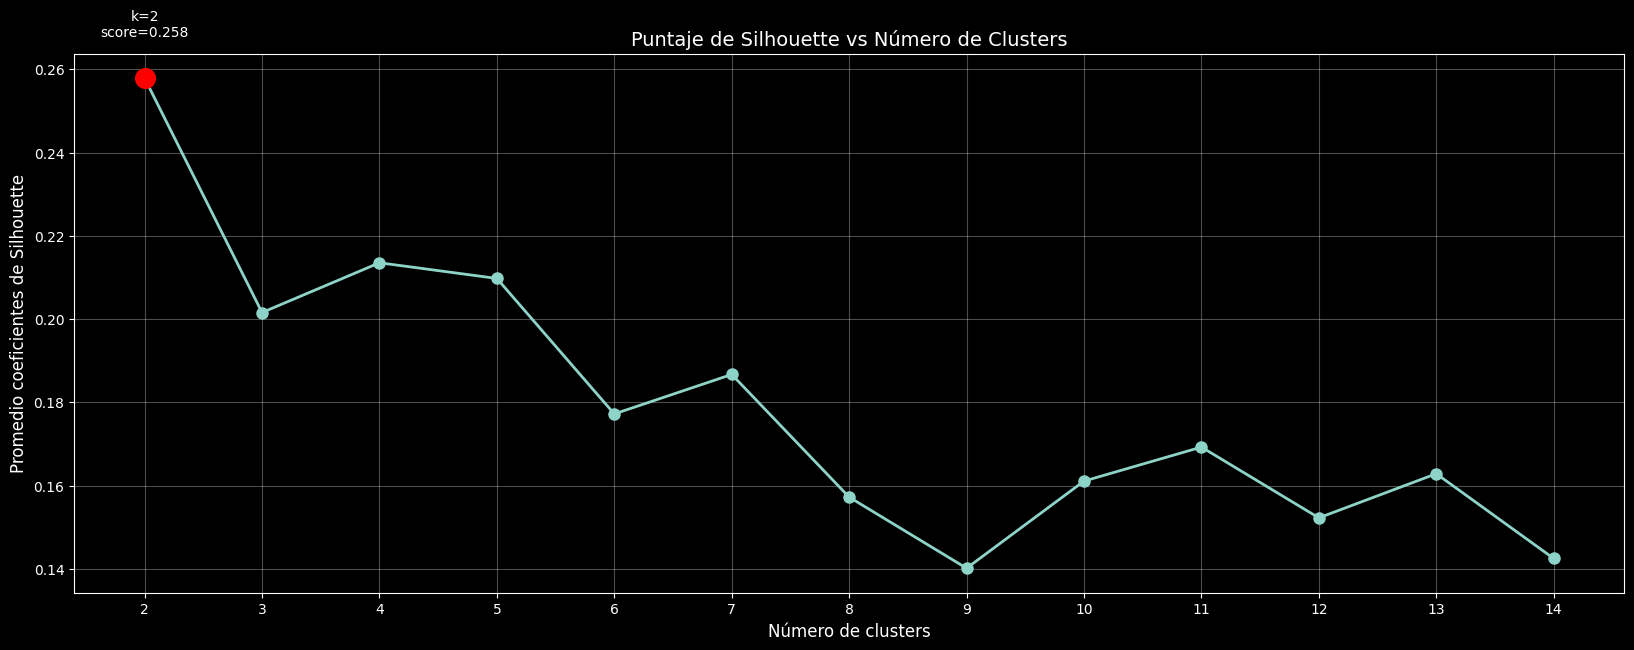

In [19]:
fig, ax = plt.subplots(figsize = (20, 7))

# Grafico de puntaje de Silhouette vs K
ax.plot(range(2, 15), silhouette_coefficients, marker='o', linewidth=2, markersize=8)
ax.set_xticks(range(2, 15))
ax.set_xlabel("Número de clusters", fontsize=12)
ax.set_ylabel("Promedio coeficientes de Silhouette", fontsize=12)
ax.set_title("Puntaje de Silhouette vs Número de Clusters", fontsize=14)
ax.grid(True, alpha=0.3)

# Marcamos el k con mejor puntaje
best_k = range(2, 15)[np.argmax(silhouette_coefficients)]
best_score = max(silhouette_coefficients)
ax.scatter(best_k, best_score, color='red', s=200, zorder=5)
ax.text(best_k, best_score + 0.01, f'k={best_k}\nscore={best_score:.3f}', 
        fontsize=10, ha='center')

In [20]:
# Comparación con etiquetas aleatorias
random_labels = kmeans.labels_.copy()
np.random.shuffle(random_labels)

print('Puntaje de Silhouette con clustering K-Means:', silhouette_coefficients[4])  # k=6
print('Puntaje de Silhouette con etiquetas aleatorias:', silhouette_score(X_pca, random_labels))

Puntaje de Silhouette con clustering K-Means: 0.1772004375397707
Puntaje de Silhouette con etiquetas aleatorias: -0.05325952291370685


El puntaje de Silhouette nos ayuda a evaluar qué tan bien definidos están los clusters. Valores más altos (cercanos a 1) indican clusters bien separados, mientras que valores cercanos a 0 sugieren clusters que se superponen. 

Comparando con etiquetas aleatorias podemos ver que el clustering K-Means efectivamente encuentra estructura en los datos de ciudades.

## [Clustering Jerárquico](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering)

Los métodos de clustering jerárquico buscan agrupar las samples más similares para formar grupos con características similares.

1. **Agglomerative**: cada sample es un cluster y en cada paso va agrupando los clusters más similares hasta quedarse con un solo cluster
2. **Divisive**: todas las samples comienzan en el mismo cluster y en cada paso va cortando las samples menos similares hasta que todas las samples sean un cluster distinto

En esta notebook vamos a ver el primer tipo de clustering jerárquico aplicado al mismo dataset de áreas urbanas.

In [21]:
# Ya no necesitamos montar el drive, el archivo está local

In [22]:
# Vamos a utilizar los datos de áreas urbanas ya cargados
# Para el clustering jerárquico, usaremos los datos estandarizados (sin PCA)
# o podemos usar los datos con PCA para comparar

# Opción 1: Usar datos estandarizados completos (todas las características)
hdata = data_scaled

# Opción 2: Si queremos usar PCA para visualización más clara
# hdata = X_pca

print("Datos para clustering jerárquico:", hdata.shape)

Datos para clustering jerárquico: (266, 17)


In [23]:
print("Dimensiones del dataset:",hdata.shape)
print("Número de ciudades:", len(city_names))

Dimensiones del dataset: (266, 17)
Número de ciudades: 266


Este dataset tiene características estandarizadas de las 267 ciudades con sus 17 métricas de calidad de vida, economía, y otros indicadores urbanos.

Vamos a tratar de agrupar a las ciudades utilizando todas sus características estandarizadas.

In [24]:
# Usaremos una muestra de los datos para el dendrograma (todas las ciudades harían el gráfico ilegible)
# Tomamos una muestra de 50 ciudades
np.random.seed(42)
sample_indices = np.random.choice(len(city_names), size=50, replace=False)
sample_data = hdata[sample_indices]
sample_names = city_names[sample_indices]

print(f"Muestra de {len(sample_indices)} ciudades para el dendrograma")
print("Primeras 10 ciudades en la muestra:", sample_names[:10])

Muestra de 50 ciudades para el dendrograma
Primeras 10 ciudades en la muestra: <StringArray>
[      'Oxford',    'Kathmandu',  'Los Angeles', 'San Salvador',
     'Budapest',       'Vienna',       'Malaga',      'Jakarta',
   'Gothenburg',       'Eugene']
Length: 10, dtype: str


Importamos un paquete de scipy que nos va a ayudar a plotear dendogramas. Lo importamos entero porque vamos a usar dos de sus clases 'dendogram' y 'linkage'.

In [25]:
# Paquete de scipy que tiene la clase 'dendograma' que vamos a utilizar
import scipy.cluster.hierarchy as shc

Vamos a realizar un dendrograma de una muestra de ciudades utilizando el método 'ward' para calcular distancias. Este método minimiza la varianza dentro de un cluster y maximiza la varianza entre clusters.

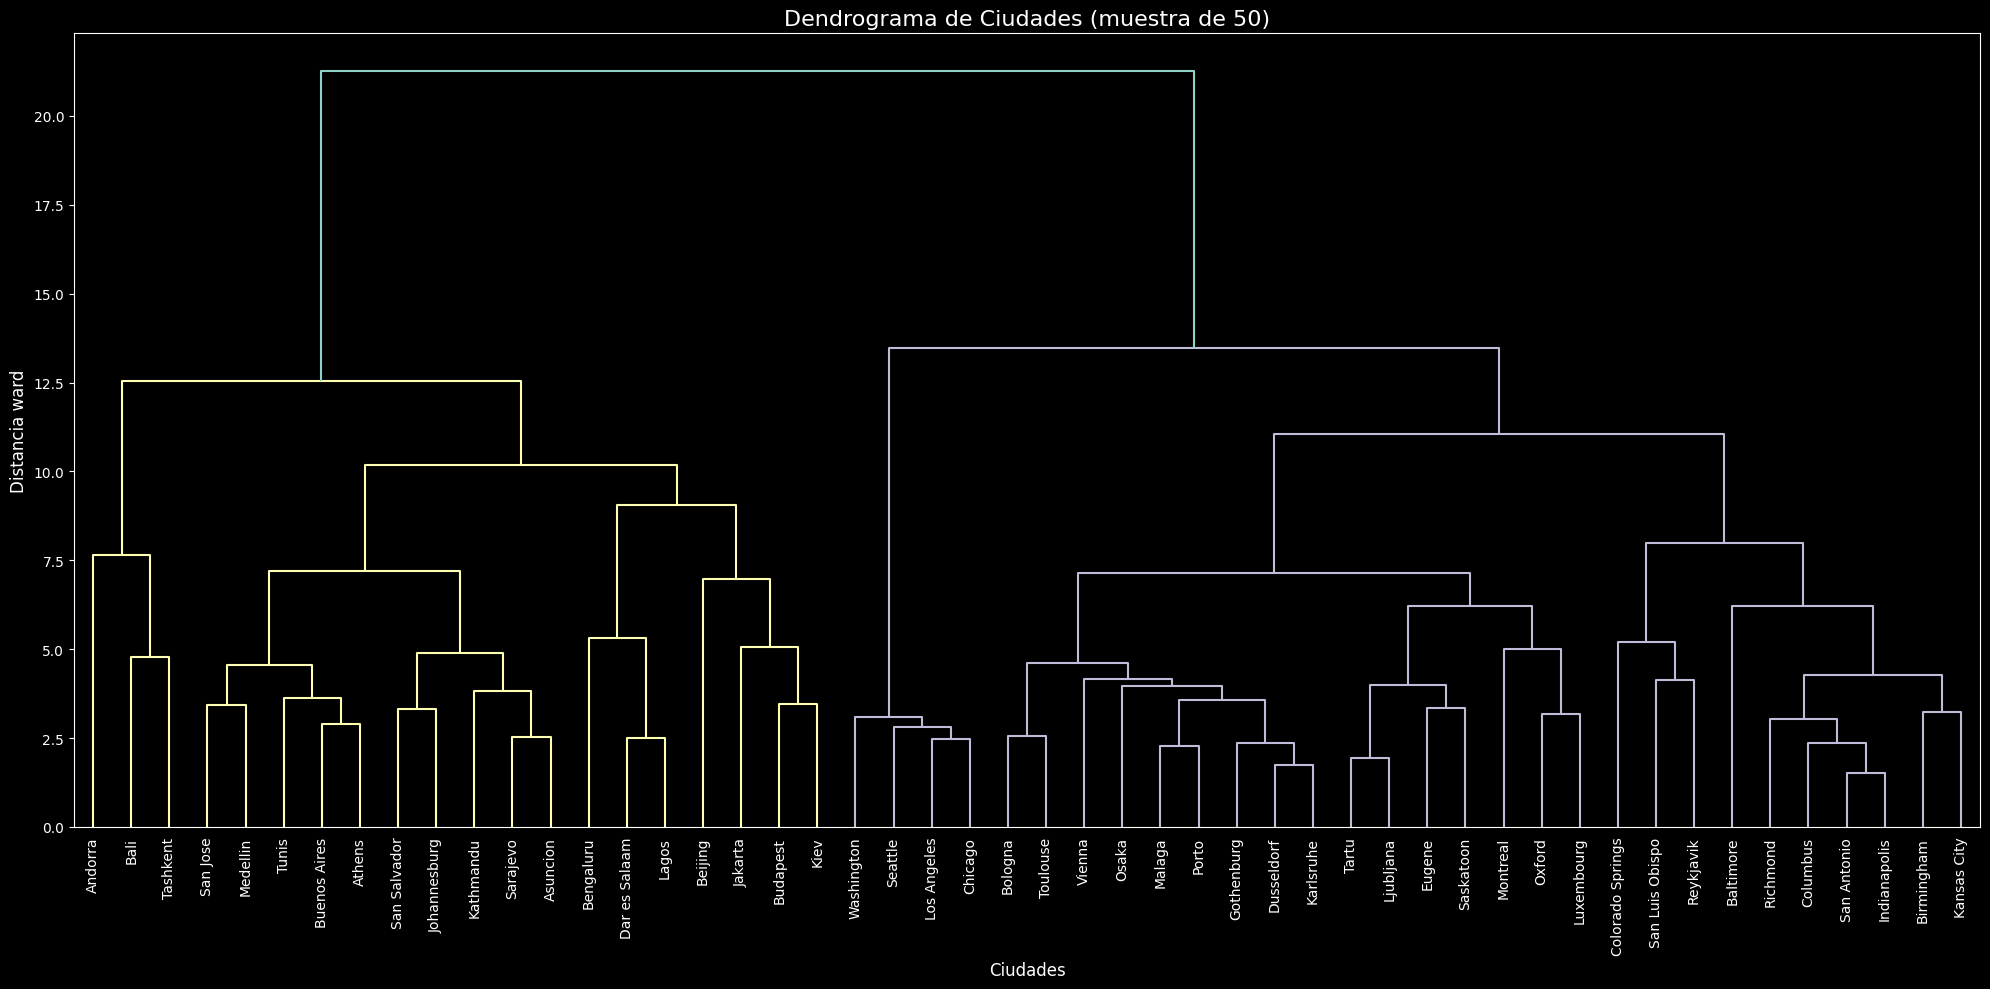

In [26]:
# Plot del dendrograma de la muestra de ciudades
plt.figure(figsize=(20, 10))
plt.title("Dendrograma de Ciudades (muestra de 50)", fontsize=16)
plt.ylabel("Distancia ward", fontsize=12)
plt.xlabel("Ciudades", fontsize=12)

# Con la función 'dendrogram' graficamos el dendrograma con nombres de ciudades
dend = shc.dendrogram(shc.linkage(sample_data, method='ward'), 
                      labels=sample_names,
                      leaf_font_size=10)
plt.xticks(rotation=90)
plt.tight_layout()

Lo que buscamos en el dendrograma es la mayor distancia vertical sin que haya una línea horizontal para hacerle un corte (representado como una línea horizontal que cruza el dendrograma) y quedarnos con k clusters (donde k es el número de líneas verticales que intersectan el corte).

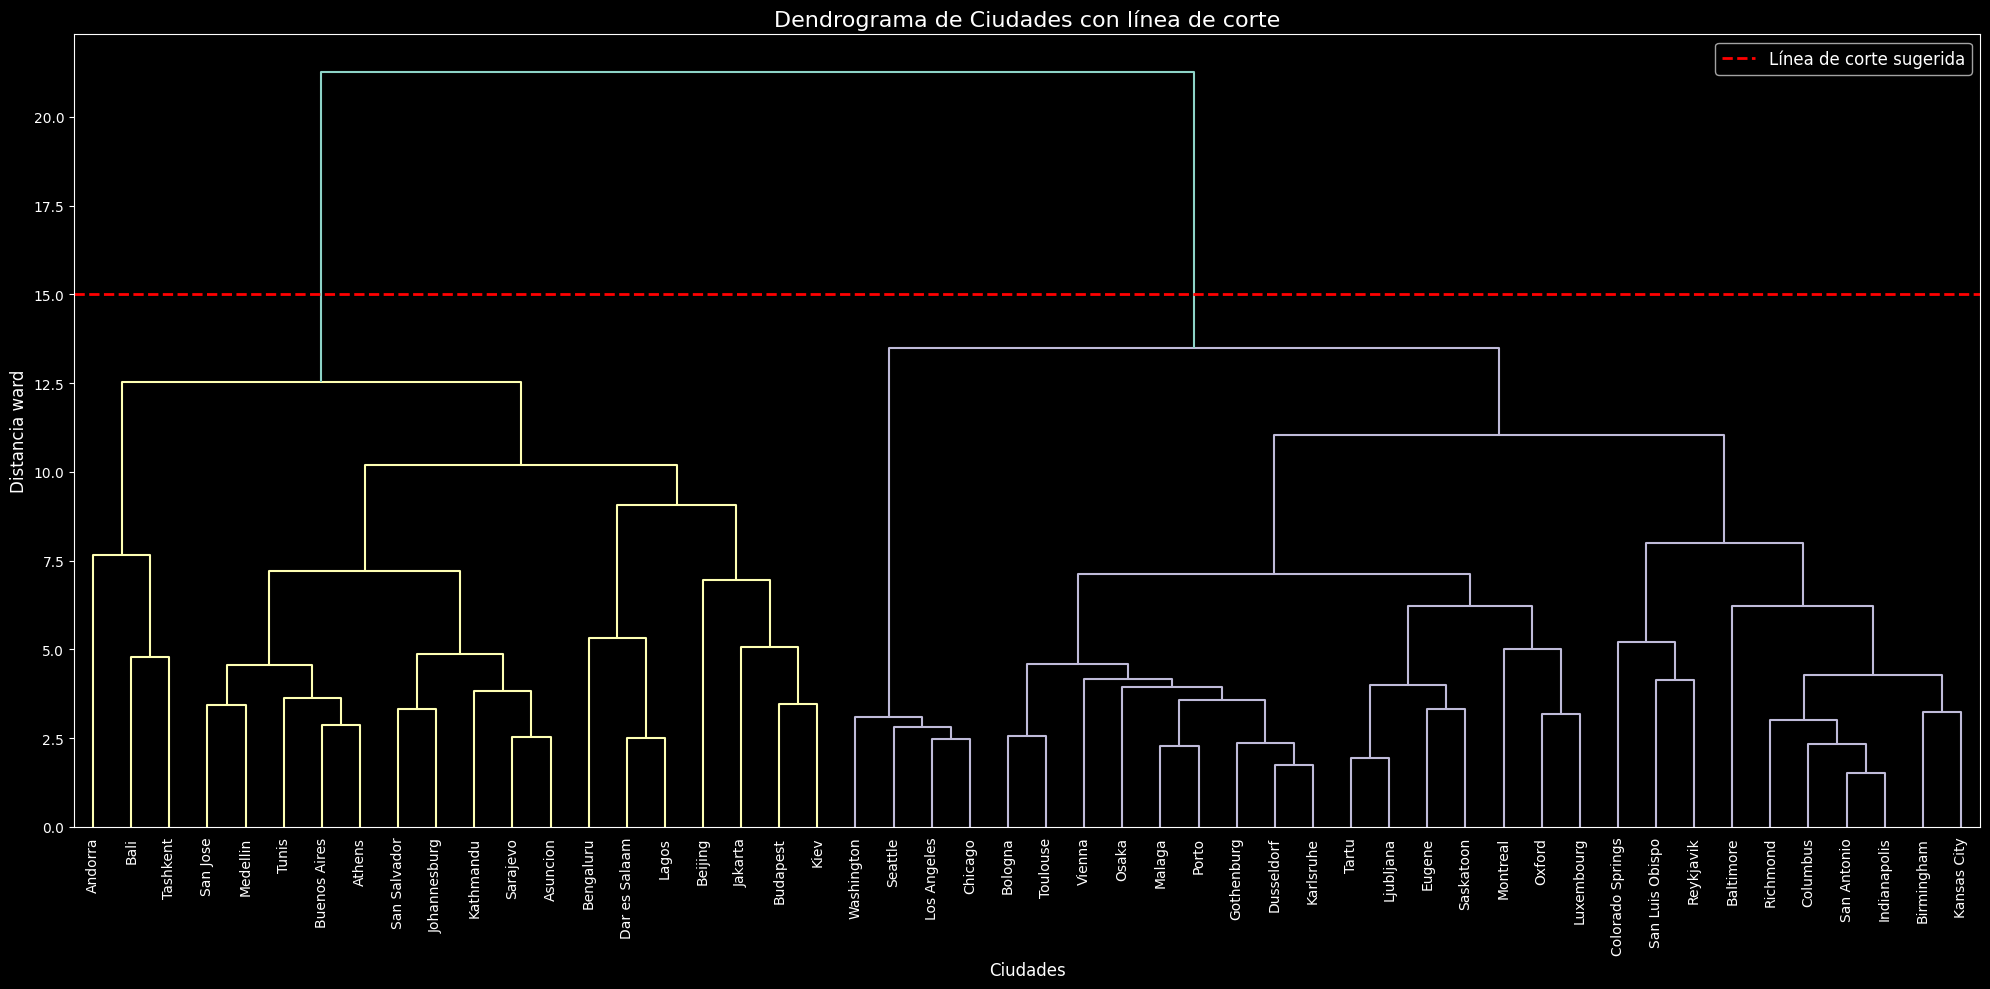

In [27]:
# Plot del dendrograma con línea de corte
plt.figure(figsize=(20, 10))
plt.title("Dendrograma de Ciudades con línea de corte", fontsize=16)
plt.ylabel("Distancia ward", fontsize=12)
plt.xlabel("Ciudades", fontsize=12)

# Dendrograma
dend = shc.dendrogram(shc.linkage(sample_data, method='ward'), 
                      labels=sample_names,
                      leaf_font_size=10)

# Línea de corte sugerida - ajustar según el dendrograma
plt.axhline(y=15, c='r', linestyle='--', linewidth=2, label='Línea de corte sugerida')
plt.legend(fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

Basándonos en el dendrograma, vamos a aplicar el método de clustering jerárquico de sklearn con un número apropiado de clusters.

In [28]:
# Importo el método de clustering jerárquico (bottom-up)
from sklearn.cluster import AgglomerativeClustering

Ahora sí aplicamos el método de clusterización jerárquica (bottom-up) con 5 clusters, la distancia euclidea para la afinidad y la distancia ward para el linkage

In [29]:
# Creamos el modelo de clustering jerárquico con 6 clusters
cluster = AgglomerativeClustering(
    n_clusters=6,
    metric='euclidean',
    linkage='ward'
)

# Lo ajustamos con todos los datos (no solo la muestra)
labels = cluster.fit_predict(hdata)

print(f'Número de clusters: {cluster.n_clusters}')
print(f'Número de ciudades por cluster:')
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} ciudades')

Número de clusters: 6
Número de ciudades por cluster:
  Cluster 0: 95 ciudades
  Cluster 1: 58 ciudades
  Cluster 2: 57 ciudades
  Cluster 3: 32 ciudades
  Cluster 4: 9 ciudades
  Cluster 5: 15 ciudades


Veamos cómo se ven las ciudades agrupadas en el espacio de componentes principales (para visualización).

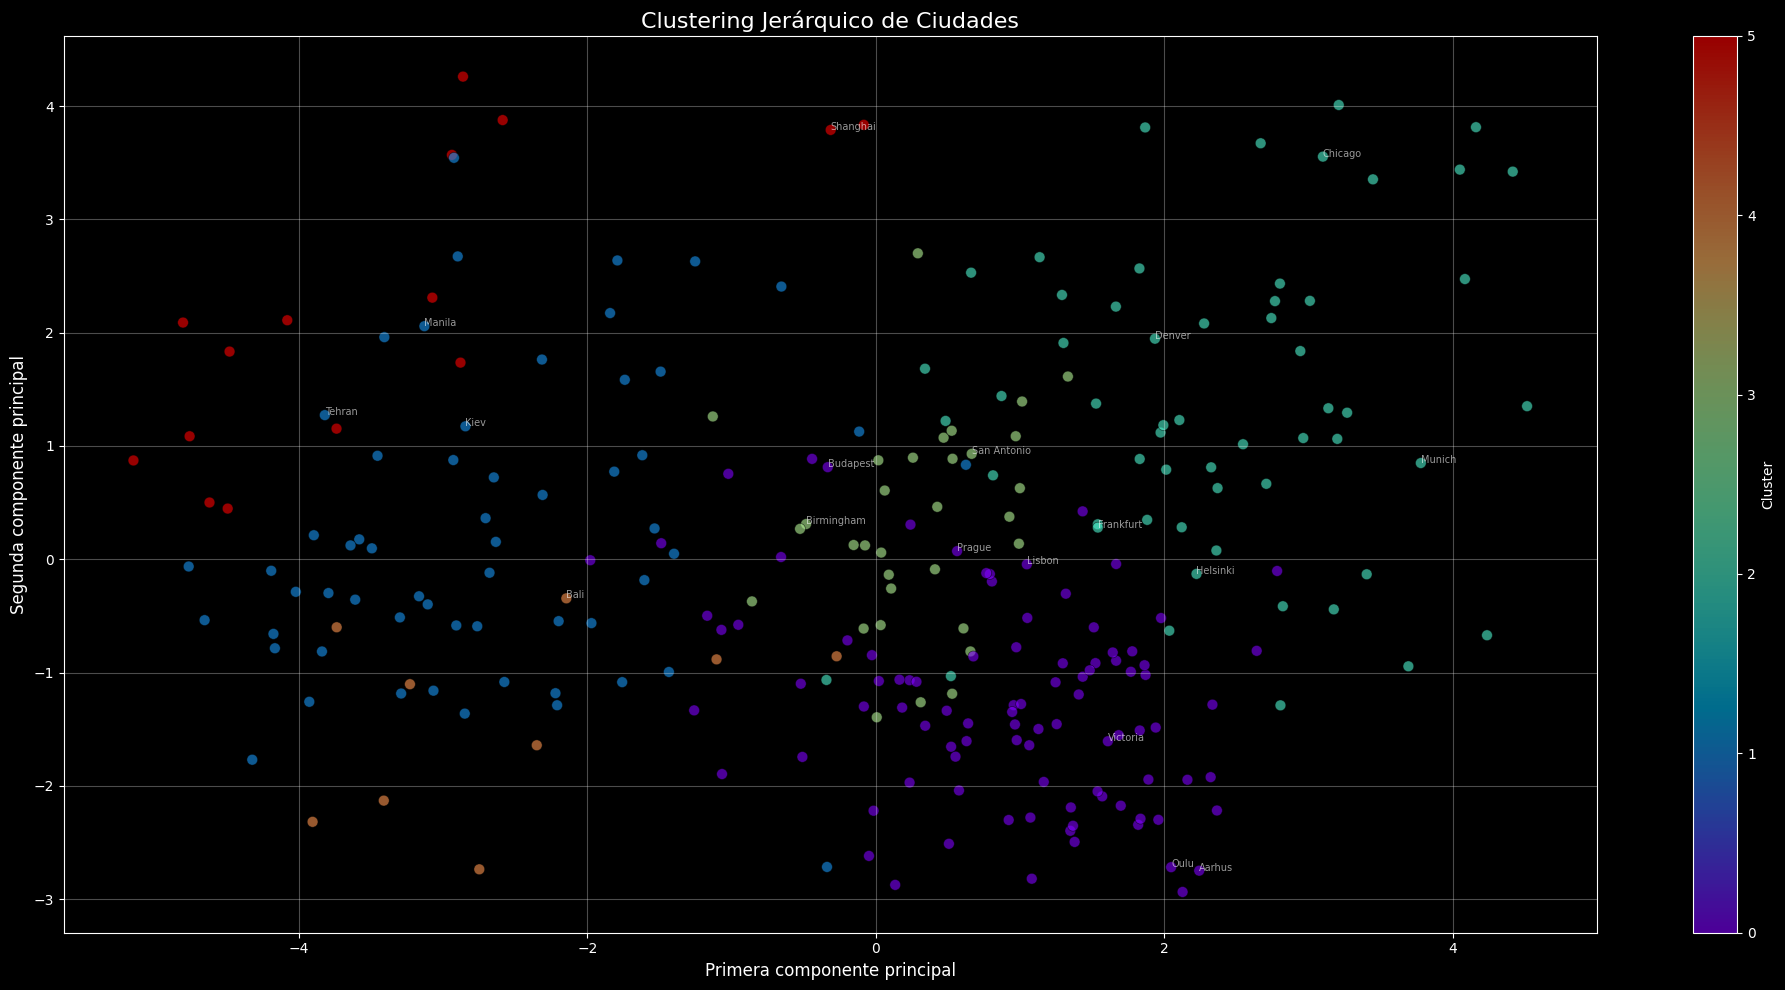

In [30]:
# Ploteamos los datos en el espacio de componentes principales con colores por cluster jerárquico
plt.figure(figsize=(20, 10))
plt.title("Clustering Jerárquico de Ciudades", fontsize=16)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster.labels_, cmap='rainbow',
                     alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')

# Mostramos algunos nombres de ciudades
for i in range(0, len(city_names), 15):
    plt.text(X_pca[i, 0], X_pca[i, 1], s=city_names[i], fontsize=7, alpha=0.6)

plt.xlabel("Primera componente principal", fontsize=12)
plt.ylabel("Segunda componente principal", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

Analicemos las características de cada cluster encontrado por el método jerárquico:

Podemos identificar diferentes tipos de ciudades:
- **Cluster 0-1**: Ciudades con ciertas características dominantes
- **Cluster 2-3**: Ciudades con diferentes perfiles de desarrollo
- **Cluster 4-5**: Ciudades con características específicas de calidad de vida o economía

El clustering jerárquico puede dar resultados diferentes a K-Means porque usa un enfoque distinto para agrupar los datos. Mientras K-Means busca minimizar la varianza intra-cluster, el método jerárquico construye una jerarquía de clusters basada en similitudes sucesivas.

## Cosas para llevarse de esta notebook

**K-Means**

```python
from sklearn.cluster import KMeans  # Importamos la clase KMeans

kmeans = KMeans(n_clusters=k, random_state=42)  # Crear el modelo con k-clusters

kmeans.fit(datos)                   # Ajustar el modelo a los datos

labels = kmeans.labels_             # Obtener las etiquetas de los k clusters para cada sample

centroids = kmeans.cluster_centers_ # Obtener las posiciones en el espacio de features del centro de los k clusters

sse = kmeans.inertia_               # Para obtener el valor de la función objetivo
```

**Estandarización y PCA**

```python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estandarizar datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Aplicar PCA
pca = PCA(n_components=10)
X_pca = pca.transform(data_scaled)

# Ver varianza explicada
pca.explained_variance_ratio_
```

**Elección de k (si no lo conocemos de antemano):**

Método del codo

```python
!pip install kneed            # Instalamos el paquete kneed con pip install

from kneed import KneeLocator # Importamos la clase para detectar el codo

kl = KneeLocator(range(1, 20), sse, curve="convex", direction="decreasing") 

kl.elbow                      # Devuelve el valor del codo
```

Puntaje de Silhouette

```python
from sklearn.metrics import silhouette_score # importamos la clase con la que se calcula el puntaje de silhouette

silhouette_score(data, kmeans.labels_) # Devuelve el puntaje de silhouette y toma como input los datos y las etiquetas asociadas
```

**Clustering Jerárquico**

```python
import scipy.cluster.hierarchy as shc # Paquete de scipy con 'dendrogram' y 'linkage'

dend = shc.dendrogram(shc.linkage(data, method='ward')) # Para hacer un dendograma usando distancia ward

from sklearn.cluster import AgglomerativeClustering # Clustering jerárquico (bottom-up)

cluster = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward') # Creamos el modelo

labels = cluster.fit_predict(data)  # Ajustamos el modelo y obtenemos las etiquetas
```


## Ejercicios propuestos

* Realizar un análisis detallado de cada cluster encontrado por K-Means. ¿Qué características definen a cada grupo de ciudades? ¿Hay patrones geográficos (por continente)?
* Comparar los resultados de K-Means con diferentes valores de k (4, 6, 8, 10). ¿Cómo cambian las agrupaciones? ¿Cuál parece más interpretable?
* Aplicar clustering jerárquico con diferentes métodos de linkage ('complete', 'average', 'single') además de 'ward'. ¿Cómo cambian los dendrogramas y clusters resultantes?
* Probar aplicar los algoritmos de clustering SIN reducción de dimensionalidad (usando directamente los datos estandarizados). Comparar el tiempo de ejecución y los resultados con el enfoque usando PCA.
* Identificar outliers: ¿Hay ciudades que no encajan bien en ningún cluster? ¿Cuáles son y por qué?
* Crear visualizaciones adicionales como gráficos de radar (spider plots) para comparar las características promedio de cada cluster.
* Experimentar con otros algoritmos de clustering disponibles en sklearn como DBSCAN o Gaussian Mixture Models.